In [10]:
import numpy as np
from numpy.lib.stride_tricks import as_strided
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
# Enable notebook mode
init_notebook_mode(connected=True)
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def ts_delay(arr,n = 1, axis = 1):
    """
    This function shifts the elements of the input array `arr` by `n` positions along the specified `axis`.
    The shifted elements are filled with NaN values.
    Parameters:
    arr (numpy.ndarray): The input array to be shifted. It can be a 1D or 2D array.
    n (int): The number of positions to shift the elements. Positive values shift to the right (for axis=1) or down (for axis=0), while negative values shift to the left (for axis=1) or up (for axis=0).
    axis (int): The axis along which to shift the elements. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:        
    numpy.ndarray: The shifted array with NaN values filling the vacated positions. 
    Example:
    >>> arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
    >>> ts_delay(arr, n=1, axis=1)      
    array([[nan,  1.,  2.],
           [nan,  4.,  5.],
           [nan,  7.,  8.]])
    """
    arr = np.asarray(arr, dtype=float)
    if(arr.ndim == 1):
        arr = np.roll(arr,n,axis=0).astype(float)
        if(n >= 0):
            arr[:n] = np.nan
        else:
            arr[n:] = np.nan
    else:
        arr = np.roll(arr,n,axis=axis).astype(float)
        if(axis == 0):
            if(n >= 0):
                arr[:n] = np.nan
            else:
                arr[n:] = np.nan
        else:
            if(n >= 0):
                arr[:, :n] = np.nan
            else:
                arr[:, n:] = np.nan
    return arr

def ts_mean(arr, n = 0, axis = 1):
    """This function calculates the mean of the input array `arr` over a rolling window of size `n` along the specified `axis`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling mean is to be calculated. It can be a 1D or 2D array.
    n (int): The size of the rolling window. It determines how many elements are included in the mean calculation. Default is 0, which means no rolling window is applied and the mean is calculated over the entire array.
    axis (int): The axis along which to calculate the rolling mean. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:
    numpy.ndarray: The array containing the rolling mean values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling mean cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([1, 2, 3, 4, 5])
    >>> ts_mean(arr, n=2)
    array([nan, 1.5, 2.5, 3.5, 4.5])
    >>> arr_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
    >>> ts_mean(arr_2d, n=2, axis=0)
    array([[nan, nan, nan],
           [2.5, 3.5, 4.5],
           [5.5, 6.5, 7.5]])"""
    arr = np.asarray(arr, dtype=float)
    if(arr.ndim == 1):
        arr = np.cumsum(arr, dtype=float)
        arr[n:] = arr[n:] - arr[:-n]
        arr[:n - 1] = np.nan
        return arr/n
    else:
        if(axis == 0):
            arr = np.cumsum(arr, axis=0, dtype=float)
            arr[n:, :] = arr[n:, :] - arr[:-n, :]
            arr[:n - 1, :] = np.nan
            return arr/n
        else:
            arr = np.cumsum(arr, axis=1, dtype=float)
            arr[:, n:] = arr[:, n:] - arr[:, :-n]
            arr[:, :n - 1] = np.nan
            return arr/n
        

def ts_max(arr, window, axis= 1):
    """
    This function calculates the maximum value over a rolling window of size `window` along the specified `axis` in the input array `arr`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling maximum is to be calculated.
    window (int): The size of the rolling window.
    axis (int): The axis along which to calculate the rolling maximum. Default is -1 (last axis).
    Returns:
    numpy.ndarray: The array containing the rolling maximum values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling maximum cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
    >>> ts_max(arr, window=2, axis=0)
    array([[nan, nan, nan],
           [4., 5., 6.],
           [7., 8., 9.]])
    """
    arr = np.asarray(arr, dtype=float)
    if(arr.ndim == 1):
        axis = 0

    # Create sliding window view
    shape = list(arr.shape)
    shape[axis] = shape[axis] - window + 1
    shape.insert(axis + 1, window)

    strides = list(arr.strides)
    strides.insert(axis + 1, arr.strides[axis])

    windows = as_strided(arr, shape=shape, strides=strides)

    result = np.nanmax(windows, axis=axis + 1)

    # Pad with NaNs to restore original shape
    out = np.full(arr.shape, np.nan, dtype=float)

    idx = [slice(None)] * arr.ndim
    idx[axis] = slice(window - 1, None)

    out[tuple(idx)] = result
    return out

def ts_min(arr, window, axis= 1):
    """
    This function calculates the minimum value over a rolling window of size `window` along the specified `axis` in the input array `arr`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling minimum is to be calculated.
    window (int): The size of the rolling window.
    axis (int): The axis along which to calculate the rolling minimum. Default is -1 (last axis).
    Returns:
    numpy.ndarray: The array containing the rolling minimum values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling minimum cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
    >>> ts_min(arr, window=2, axis=0)
    array([[nan, nan, nan],
           [1., 2., 3.],
           [4., 5., 6.]])
    """
    arr = np.asarray(arr, dtype=float)
    if(arr.ndim == 1):
        axis = 0

    # Create sliding window view
    shape = list(arr.shape)
    shape[axis] = shape[axis] - window + 1
    shape.insert(axis + 1, window)

    strides = list(arr.strides)
    strides.insert(axis + 1, arr.strides[axis])

    windows = as_strided(arr, shape=shape, strides=strides)

    result = np.nanmin(windows, axis=axis + 1)

    # Pad with NaNs to restore original shape
    out = np.full(arr.shape, np.nan, dtype=float)

    idx = [slice(None)] * arr.ndim
    idx[axis] = slice(window - 1, None)

    out[tuple(idx)] = result
    return out

def ts_std(arr, n = 0, axis = 1):
    """
    This function calculates the standard deviation of the input array `arr` over a rolling window of size `n` along the specified `axis`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling standard deviation is to be calculated. It can be a 1D or 2D array.
    n (int): The size of the rolling window. It determines how many elements are included in the standard deviation calculation. Default is 0, which means no rolling window is applied and the standard deviation is calculated over the entire array.
    axis (int): The axis along which to calculate the rolling standard deviation. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:    
    numpy.ndarray: The array containing the rolling standard deviation values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling standard deviation cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([1, 2, 3, 4, 5])
    >>> ts_std(arr, n=2)
    [nan, 0.35355339, 0.35355339, 0.35355339, 0.35355339]
    >>> arr_2d = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
    >>> ts_std(arr_2d, n=2, axis=0)
    [[       nan 0.35355339 0.35355339]
    [       nan 0.35355339 0.35355339 ]
    [       nan 0.35355339 0.35355339]]
    """
    std = arr - ts_mean(arr, n, axis)
    std = (std * std)/n
    std = np.sqrt(std)
    return std

def ts_zscore(arr, n = 0, axis = 1):
    """
    This function calculates the z-score of the input array `arr` over a rolling window of size `n` along the specified `axis`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling z-score is to be calculated.
    n (int): The size of the rolling window. It determines how many elements are included in the z-score calculation.
    axis (int): The axis along which to calculate the rolling z-score. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:
    numpy.ndarray: The array containing the rolling z-score values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling z-score cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([1, 2, 3, 4, 5])
    >>> ts_zscore(arr, n=2)
    [       nan 1.41421356 1.41421356 1.41421356 1.41421356]
    """
    mean = ts_mean(arr, n, axis)
    std = ts_std(arr, n, axis)
    zscore = (arr - mean)/std
    return zscore

def ffill(arr, axis=1):
    """
    This function performs forward fill (ffill) on the input array `arr` along the specified `axis`. 
    Forward fill is a method of filling missing values in a time series by propagating the last valid observation forward until a new valid observation is encountered.
    Parameters:
    arr (numpy.ndarray): The input array containing missing values (NaN) that need to be filled. It can be a 1D or 2D array.
    axis (int): The axis along which to perform the forward fill. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:
    numpy.ndarray: The array with missing values filled using forward fill. The shape of the output array is the same as the input array, with NaN values replaced by the last valid observation along the specified axis.
    Example:
    >>> arr = np.array([[np.nan, 2, np.nan, 4.0, np.nan, 6.0],
    ...                 [1.0, np.nan, np.nan, 4.0, np.nan, 6.0],
    ...                 [1.0, np.nan, np.nan, 4.0, np.nan, 6.0]])
    >>> ffill(arr, axis=0)
    [[nan  2. nan  4. nan  6.]
    [ 1.  2. nan  4. nan  6.]
    [ 1.  2. nan  4. nan  6.]]
    """
    arr = np.asarray(arr)

    if axis == 1:
        mask = ~np.isnan(arr)

        idx = np.where(mask, np.arange(len(arr)), 0)
        idx = np.maximum.accumulate(idx)

        return np.take_along_axis(arr, idx)

    elif axis == 0:
        mask = ~np.isnan(arr)

        idx = np.where(mask, np.arange(arr.shape[0])[:, None], 0)
        idx = np.maximum.accumulate(idx, axis=0)

        return np.take_along_axis(arr, idx, axis=0)

    else:
        raise ValueError("axis must be 0 or 1")

def ts_median(arr, n=0, axis=1):
    """
    This function calculates the median of the input array `arr` over a rolling window of size `n` along the specified `axis`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling median is to be calculated.
    n (int): The size of the rolling window. It determines how many elements are included in the median calculation.
    axis (int): The axis along which to calculate the rolling median. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:
    numpy.ndarray: The array containing the rolling median values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling median cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([1, 2, 3, 4, 5])
    >>> ts_median(arr, n=2)
    [       nan 1.5 2.5 3.5 4.5]
    """
    arr = np.asarray(arr)

    if arr.ndim == 1:
        shape = (len(arr) - n + 1, n)
        strides = (arr.strides[0], arr.strides[0])

        windows = as_strided(arr, shape=shape, strides=strides)

        out = np.full(arr.shape, np.nan)
        out[n-1:] = np.median(windows, axis=1)
        return out

    if axis == 1:
        m, T = arr.shape

        shape = (m, T - n + 1, n)
        strides = (arr.strides[0], arr.strides[1], arr.strides[1])

        windows = as_strided(arr, shape=shape, strides=strides)

        out = np.full(arr.shape, np.nan)
        out[:, n-1:] = np.median(windows, axis=2)
        return out

    else:
        m, T = arr.shape
        shape = (m - n + 1, n, T)
        strides = (arr.strides[0], arr.strides[0], arr.strides[1])

        windows = as_strided(arr, shape=shape, strides=strides)

        out = np.full(arr.shape, np.nan)
        out[n-1:, :] = np.median(windows, axis=1)
        return out
    
def ts_skewness(arr, n, axis = 1):
    """
    This function calculates the skewness of the input array `arr` over a rolling window of size `n` along the specified `axis`.
    Parameters:
    arr (numpy.ndarray): The input array for which the rolling skewness is to be calculated.
    n (int): The size of the rolling window. It determines how many elements are included in the skewness calculation.
    axis (int): The axis along which to calculate the rolling skewness. 0 for rows and 1 for columns. Default is 1 (columns).
    Returns:
    numpy.ndarray: The array containing the rolling skewness values. The shape of the output array is the same as the input array, with NaN values filling the positions where the rolling skewness cannot be calculated due to insufficient data points.
    Example:
    >>> arr = np.array([1, 2, 3, 4, 5])
    >>> ts_skewness(arr, n=2)
    [       nan 0. 0. 0. 0.]
    """
    mean = ts_mean(arr, n, axis)
    median = ts_median(arr, n, axis)
    std = ts_std(arr, n, axis)
    skewness = (3*(mean - median))/std
    return skewness

def n2z(arr):
    """
    Converting nan values in a numpy matrix to 0
    """
    return np.nan_to_num(arr, nan=0)

def simulate(alpha,ret,tc = 0.05):
    """
    Simulate bar-level PnL (profit and loss) with transaction cost adjustment.

    Parameters
    ----------
    alpha : array-like
        Trading signal or strategy weights at each time step.
    ret : array-like
        Asset returns corresponding to the signals.
    tc : float, optional
        Transaction cost rate + slippage (default is 0.05 bips).

    Returns
    -------
    barpnl : array-like
        Raw profit and loss without transaction cost adjustment.
    barpnl_slipp : array-like
        Profit and loss adjusted for transaction costs (slippage).
    """
    tc = tc*0.0001
    alpha_d1 = ts_delay(alpha,1)
    barpnl = alpha_d1*ret
    turnover = np.abs(alpha - n2z(alpha_d1))
    barpnl_slipp = barpnl - turnover*tc
    
    return barpnl, barpnl_slipp

def simulate_and_plot_1d(alpha,ret,datetimes,tc = 0.05):
    """
    Simulate and plot cumulative PnL (profit and loss) with and without transaction costs.

    Parameters
    ----------
    alpha : array-like
        Trading signal or strategy weights at each time step.
    ret : array-like
        Asset returns corresponding to the signals.
    datetimes : array-like
        Sequence of datetime values used for plotting the PnL series.
    tc : float, optional
        Transaction cost rate + slippage (default is 0.05 bips).

    Returns
    -------
    None
        Displays an interactive plot with two lines:
        - 'pnl': cumulative PnL without transaction cost adjustment
        - 'pnl_slipp': cumulative PnL adjusted for transaction costs
    """

    barpnl, barpnl_slipp = simulate(alpha,ret,tc)
    barpnl = np.nan_to_num(barpnl, nan=np.nan, posinf=np.nan, neginf=np.nan)
    barpnl_slipp = np.nan_to_num(barpnl_slipp, nan=np.nan, posinf=np.nan, neginf=np.nan)
    pnlseries = np.nancumsum(barpnl)
    pnlseries_slipp = np.nancumsum(barpnl_slipp)

    

    # iplot([go.Scatter(x = datetimes, y = pnlseries, name = 'pnl'),
    #        go.Scatter(x = datetimes, y = pnlseries_slipp, name = 'pnl_slipp')])

    # Convert string datetimes ("%Y%m%d%H%M") into datetime objects
    datetimes_dt = [datetime.strptime(d, "%Y%m%d%H%M") for d in datetimes]

    plt.figure(figsize=(18, 8))
    plt.plot(datetimes_dt, pnlseries, label='pnl')
    plt.plot(datetimes_dt, pnlseries_slipp, label='pnl_slipp')

    plt.xlabel("Date")
    plt.ylabel("Cumulative PnL")
    plt.title("PnL Simulation with and without Transaction Costs")
    plt.legend()

    # Format x-axis ticks for readability
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
    plt.xticks(rotation=90, ha='center')  # rotate and center-align

    plt.tight_layout()
    plt.show()

    



C:\Users\ugupt\AppData\Local\Temp\ipykernel_31688\2836714638.py:9: RuntimeWarning: divide by zero encountered in divide
  alpha = np.sign(np.log(close/ts_delay(close,1)))
C:\Users\ugupt\AppData\Local\Temp\ipykernel_31688\2836714638.py:9: RuntimeWarning: divide by zero encountered in log
  alpha = np.sign(np.log(close/ts_delay(close,1)))
C:\Users\ugupt\AppData\Local\Temp\ipykernel_31688\2836714638.py:16: RuntimeWarning: divide by zero encountered in divide
  ret = (close/ts_delay(close,1)) - 1


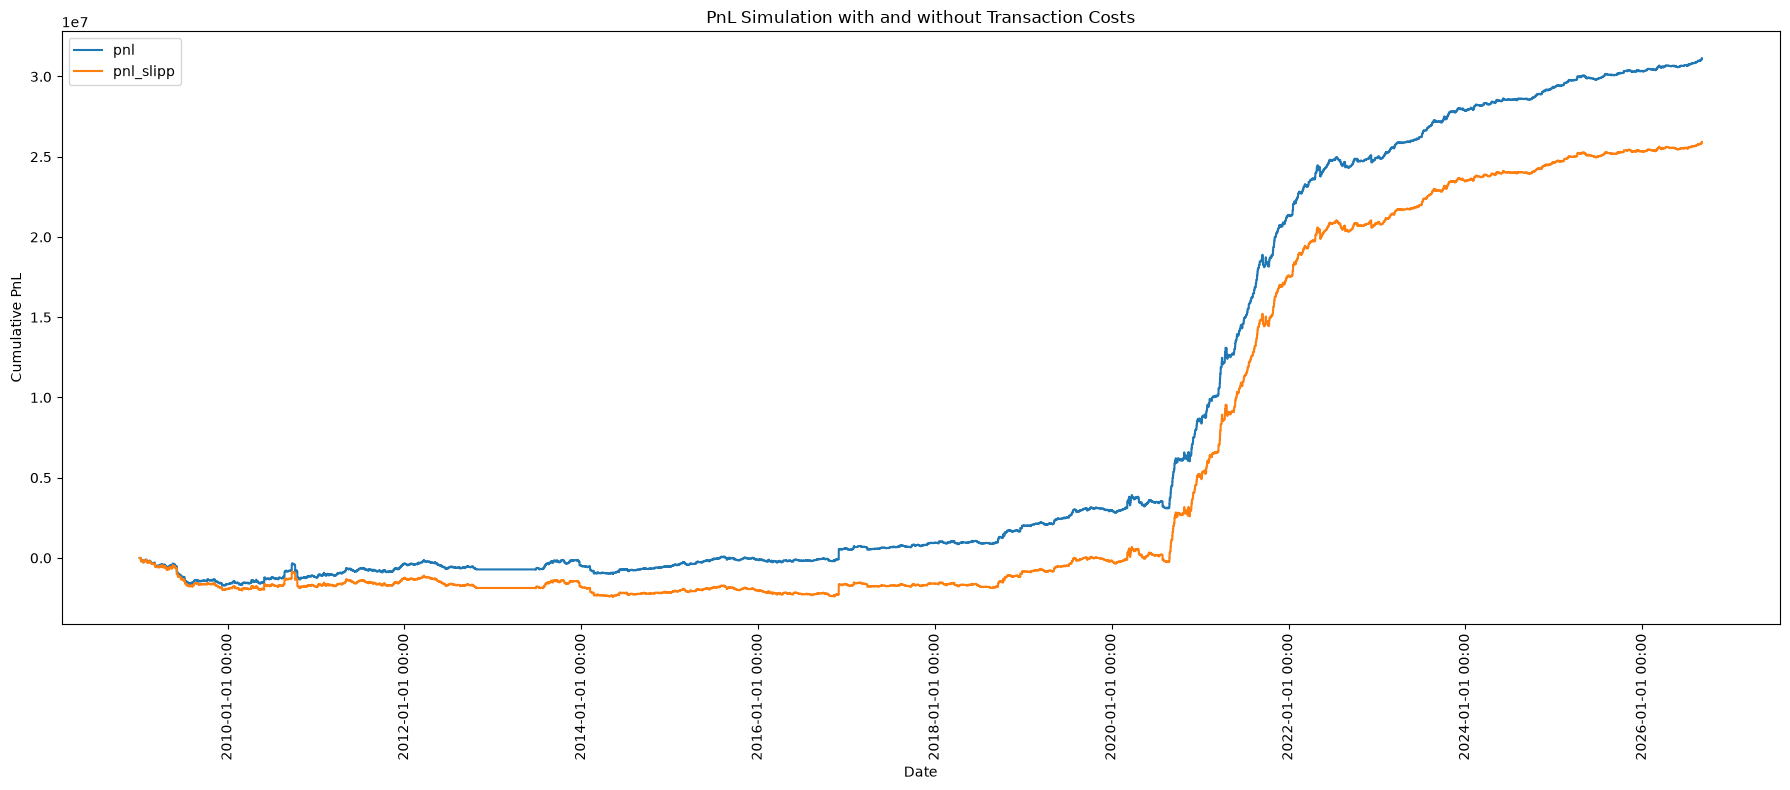

In [11]:
##### Loading NIFTY Data ####################################

int_datetimes = np.load('./Data/hybride/datetimes.npy', allow_pickle=True)
datetimes = np.array([str(x) for x in int_datetimes])
close = np.load('./Data/hybride/close.npy', allow_pickle=True)

#################### Alpha Creation ##########################

alpha = np.sign(np.log(close/ts_delay(close,1)))
alpha[np.where(int_datetimes%10000 == 915)] = np.nan
alpha = ffill(alpha)
alpha[np.where((int_datetimes%10000 < 915) | (int_datetimes%10000 > 1525))] = 0

################# Final steps ###############################

ret = (close/ts_delay(close,1)) - 1
booksize = alpha * 25e5


simulate_and_plot_1d(booksize,ret,datetimes,2.5)



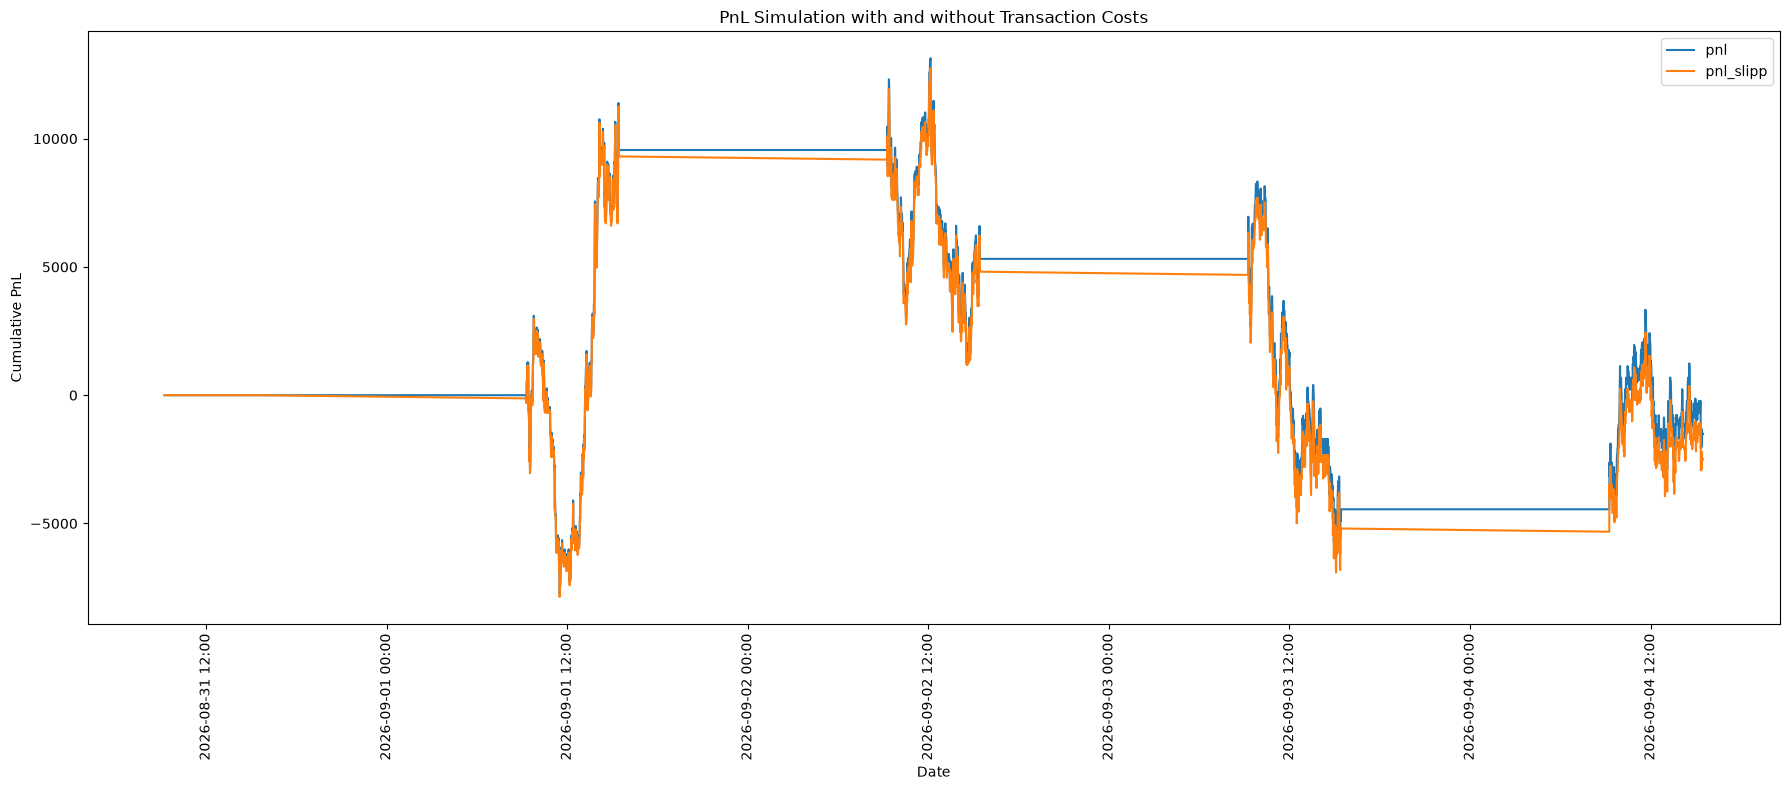

In [12]:
##### Loading NIFTY Data ####################################

datetimes = np.load('./Data/1min/datetimes.npy', allow_pickle=True)
int_datetimes = np.array([int(x) for x in datetimes])
close = np.load('./Data/1min/close.npy', allow_pickle=True)
openp = np.load('./Data/1min/openp.npy', allow_pickle=True)

#################### Alpha Creation ##########################

alpha = np.sign(np.log(openp/ts_delay(close,1)))
alpha[np.where(int_datetimes%10000 != 915)] = np.nan
alpha = ffill(alpha)
alpha[np.where((int_datetimes%10000 < 915) | (int_datetimes%10000 > 1525))] = 0

################# Final steps ###############################

ret = (close/ts_delay(close,1)) - 1
booksize = alpha * 25e5


simulate_and_plot_1d(booksize,ret,datetimes,0.5)

